In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("C:/Users/dasar/Downloads/Synthetic.csv")
data.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [3]:
data.drop(columns = ["Unnamed: 0"],inplace =True)
data.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [4]:
x = data.iloc[:,0].values
y = data.iloc[:,1].values

x = (x-np.mean(x))/ np.std(x)

theta_0 = np.array(np.random.randn()).reshape(1,1)
theta_1 = np.array(np.random.randn()).reshape(1,1)

learning_rate = 0.0001
epochs = 1000
tolerance = 0.001
batch_size = 32

m = len(x)
losses=[]


In [5]:
for epoch in range(epochs):
    indices = np.random.permutation(m)
    x = x[indices]
    y = y[indices]

    for i in range(0,m,batch_size):
        x_batch = x[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        y_hat = theta_0*x_batch + theta_1
        error = y_hat - y_batch

        d_theta_0 = np.mean(x_batch*error)
        d_theta_1 = np.mean(error)

        theta_0 = theta_0 - learning_rate*d_theta_0
        theta_1 = theta_1 - learning_rate*d_theta_1

    y_hat_all = theta_0*x + theta_1
    loss = 1/2 * np.mean((y_hat_all - y)**2)

    losses.append(loss)

    if loss<= tolerance:
        break

Text(0, 0.5, 'Loss MSE')

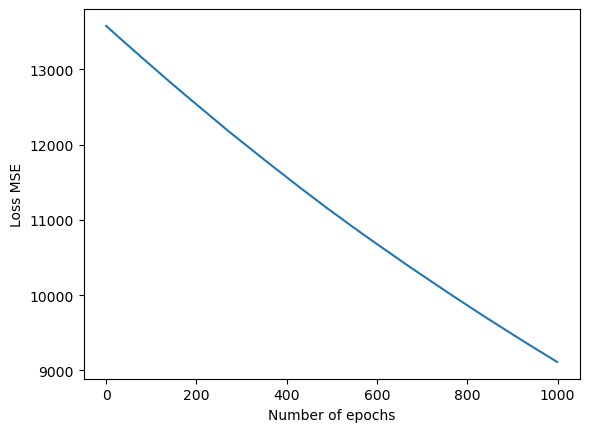

In [6]:
plt.plot(losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss MSE")